**Run Predictor model based on Deliveries Data:**

In this project, I aim to build a Machine Learning model to predict the expected number of runs scored for a given cricket delivery, based on detailed ball-tracking features. The dataset contains a mix of numerical and categorical features such as ball speed, swing angle, release position, and the bowler's and batsman's attributes. This project involves an end-to-end workflow, including data preprocessing, exploratory data analysis (EDA), feature engineering, model selection, evaluation, and interpretation.

The insights from this model can help cricket coaches and analysts strategize effectively, such as identifying optimal bowling areas to minimize runs or understanding general trends in scoring patterns.


**Exploratory Data Analysis:**

This section deals with understanding data. It can be used to gain a deep understanding of data before making assumptions, helping in identify patterns, outliers, missing values, and potential issues within the dataset.

In [93]:
#import all necessary libraries
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from matplotlib import pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('sample_data/data.csv')

#first look of the data
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200789 entries, 0 to 200788
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   release_speed_kph        200333 non-null  float64
 1   swing_angle              200534 non-null  float64
 2   deviation                194981 non-null  float64
 3   release_position_y       200527 non-null  float64
 4   release_position_z       200402 non-null  float64
 5   bounce_position_y        200465 non-null  float64
 6   bounce_position_x        200520 non-null  float64
 7   crease_position_y        200535 non-null  float64
 8   crease_position_z        200506 non-null  float64
 9   stumps_position_y        200523 non-null  float64
 10  stumps_position_z        200506 non-null  float64
 11  bounce_velocity_ratio_z  200496 non-null  float64
 12  release_angle            200533 non-null  float64
 13  drop_angle               200510 non-null  float64
 14  boun

**Handling missing values:**

In context of this dataset, in my opinion, missing values have to be removed as it cannot be filled by mean(for numerical data) and mode(for categorical data) values because every delivery is different and needs to be trained for the particular inputs. Generating mean input values might result in low prediction accuracy of the data.

In [94]:
# Drop rows with missing values as it cannot be substituted
df.dropna()

,release_speed_kph,swing_angle,deviation,release_position_y,release_position_z,bounce_position_y,bounce_position_x,crease_position_y,crease_position_z,stumps_position_y,stumps_position_z,bounce_velocity_ratio_z,release_angle,drop_angle,bounce_angle,batting_hand,bowling_hand,bowling_type,runs,wicket
0,87.42,-1.64,2.44,0.78,2.12,0.27,5.35,0.23,0.46,0.21,0.49,-0.50,-2.81,-15.69,8.78,left,right,spin,1,0
1,141.37,0.83,-0.36,-0.76,2.10,-0.15,7.29,0.19,0.71,0.27,0.80,-0.59,-8.88,-12.34,7.90,right,right,pace,1,0
2,133.41,-0.80,0.16,0.30,1.83,0.15,3.78,0.11,0.21,0.10,0.27,-0.47,-4.72,-9.53,4.91,right,left,pace,1,0
4,89.12,0.81,-2.45,-0.62,2.15,0.13,4.03,0.18,0.45,0.21,0.57,-0.57,-0.72,-16.55,10.25,right,right,spin,1,0
6,96.64,0.32,0.71,-0.84,2.05,-0.01,5.36,0.32,0.50,0.42,0.57,-0.52,-2.52,-15.39,8.76,right,left,spin,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200784,86.25,-2.68,3.90,1.10,1.81,0.24,5.51,0.14,0.60,0.12,0.66,-0.63,-1.26,-14.82,11.17,left,right,spin,6,0
200785,88.19,0.90,2.95,0.92,2.12,0.17,3.87,0.19,0.59,0.20,0.77,-0.71,-0.31,-16.44,13.51,left,right,spin,1,0
200786,128.75,2.05,-0.58,-0.39,1.96,-0.01,1.91,0.02,0.12,0.06,0.26,-0.66,-3.50,-10.14,7.10,right,right,pace,1,0
200787,135.15,1.22,-0.08,0.55,1.99,0.13,7.15,-0.03,0.75,-0.07,0.85,-0.68,-8.23,-11.44,8.36,right,left,pace,0,0


**Label encoding:**

For training the model, we need to have numerical data for better accuracy. As the dataset contains columns with categorical values, encoding needs to be performed for an efficient prediction. The columns 'batting_hand', 'bowling_hand', 'bowling_type' are encoded into binary values as can be seen below:

In [95]:
#Encoding categorical variables
def batting_hand_encode(row):
  if row['batting_hand'] == 'left':
    return 1        #left handed bat means 1
  return 0       #right handed bat means 0

def bowling_hand_encode(row):
  if row['bowling_hand'] == 'left':
    return 1      #left handed bowl means 1
  return 0       #right handed bowl means 0

def bowling_type_encode(row):
  if row['bowling_type'] == 'spin':
    return 1     #spin bowling implies 1
  return 0      #fast bowling implies 0

col = df.apply(batting_hand_encode, axis=1)
df = df.assign(batting_hand_encoded=col.values)

col = df.apply(bowling_hand_encode, axis=1)
df = df.assign(bowling_hand_encoded=col.values)

col = df.apply(bowling_type_encode, axis=1)
df = df.assign(bowling_type_encoded=col.values)

df = df.sample(frac=1)

**Finding relations:**

To check the randomness or the relation between columns in the dataset, a correlation matrix has been plotted. It can be inferred from the correlation matrix below that the data is highly random and suggests that training any model for this dataset would provide a lower accuracy. In cricket terms, it is also a valid point to say that each ball is almost unique given all the angles and the coordinates of its trajectory. From this particular plot, it can be seen that the 'runs' column is highly uncorrelated between other columns in the dataset suggesting a inaccurate prediction for runs scored.

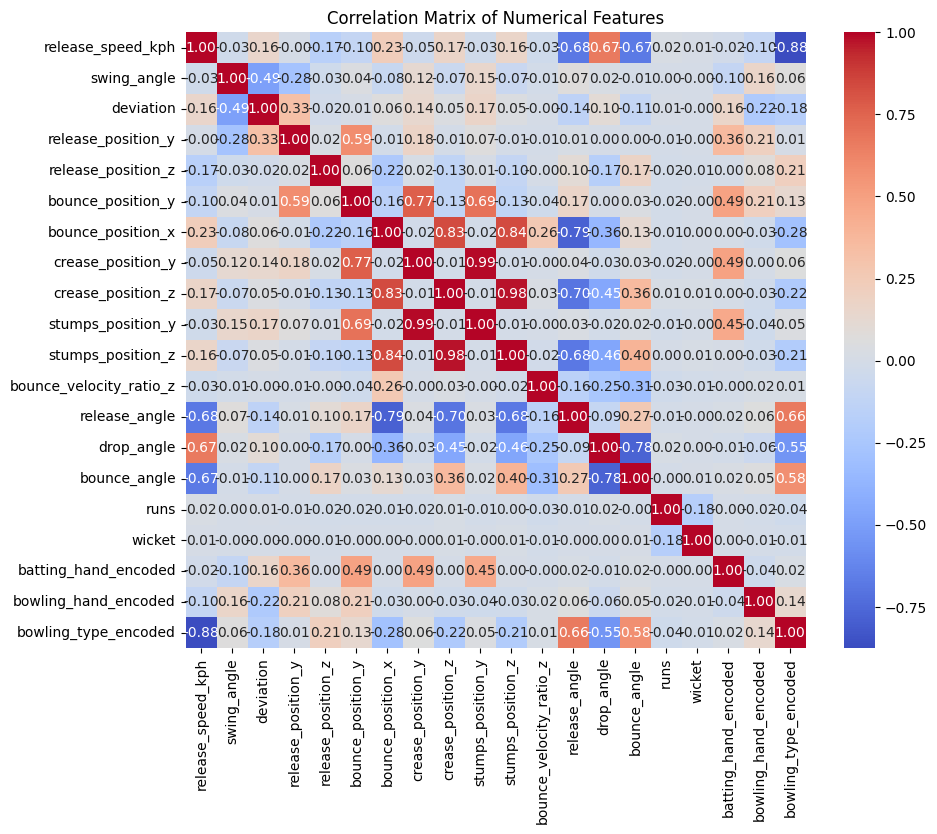

In [96]:
categorical_columns = ['batting_hand', 'bowling_hand', 'bowling_type']
numerical_data = df.drop(columns=categorical_columns)  # Drop categorical columns

# Compute the correlation matrix
correlation_matrix = numerical_data.corr()

# Plot the correlation matrix
plt.figure(figsize=(10, 8))  # Adjust size as needed
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

**Training and Testing the Dataset:**

For the purpose of this project, I have considered 90% of the data for training purpose and 10% for testing purpose given the randomness of the dataset.

I have used random forest classifier to begin with for the purpose of this project as the dataset is complex. I have chosen a classification model instead of a regression model as the output expected is considered a discrete class.

In [97]:
total_size = df.shape[0]
train_size = int(total_size*0.9)
test_size = total_size - train_size

train_X = df[:train_size][['release_speed_kph', 'swing_angle', 'deviation', 'release_position_y',
       'release_position_z', 'bounce_position_y', 'bounce_position_x',
       'crease_position_y', 'crease_position_z', 'stumps_position_y',
       'stumps_position_z', 'bounce_velocity_ratio_z', 'release_angle',
       'drop_angle', 'bounce_angle', 'batting_hand_encoded', 'bowling_hand_encoded',
       'bowling_type_encoded',]].to_numpy()

train_Y = df[:train_size][['runs']].to_numpy()

test_X = df[train_size:][['release_speed_kph', 'swing_angle', 'deviation', 'release_position_y',
       'release_position_z', 'bounce_position_y', 'bounce_position_x',
       'crease_position_y', 'crease_position_z', 'stumps_position_y',
       'stumps_position_z', 'bounce_velocity_ratio_z', 'release_angle',
       'drop_angle', 'bounce_angle', 'batting_hand_encoded', 'bowling_hand_encoded',
       'bowling_type_encoded',]].to_numpy()

test_Y = df[train_size:][['runs']].to_numpy()

Note: Due to time constraint and higher run time of certain models(XGBoost), this project is restricted to showcase of results for a RandomForestClassifier model.

In [98]:
clf = RandomForestClassifier()
clf.fit(train_X, train_Y)
pred_Y = clf.predict(test_X)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [105]:
# Calculate variance of the target variable (runs)
target_variance = np.var(test_Y)

# Calculate variance of the model's predictions
prediction_variance = np.var(pred_Y)

# Print the variances
print(f"Variance of Target (Runs): {target_variance}")
print(f"Variance of Predictions: {prediction_variance}")

Variance of Target (Runs): 2.634903803862883
Variance of Predictions: 0.3939311972303753


**Plotting a confusion matrix:**

Confusion matrix helps us in understanding how well the model is predicting an outcome by giving us a predicted value against its true value in the test case scenarios. According to the matrix below, even though the data is highly random, it can be seen that the model is comparitively more accurate in predicting the scores of 0 and 1 compared to other predictions.

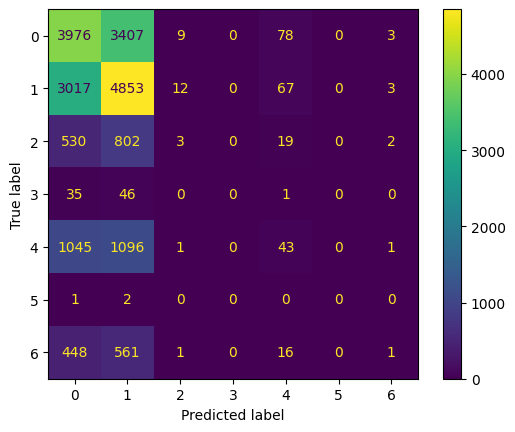

In [104]:
test_Y_reshaped = test_Y.reshape((test_Y.shape[0], ))
cm = confusion_matrix(test_Y_reshaped, pred_Y)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
# Then just plot it:
disp.plot()
# And show it:
plt.show()

So based on the confusion matrix produced above, if we consider the percentage accuracies of the model for each prediction rather than the whole model accuracy, it can be seen that the model is around 61% accurate in predicting a score of 1 and more than 50% accurate in predicting 0 and not efficient in predicting other scores indicating randomness in data or insufficient data.

In [101]:
cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm.diagonal()

array([0.53204871, 0.61028672, 0.00221239, 0.        , 0.01967063,
       0.        , 0.00097371])

**Answers to the Task questions:**

1. Which Machine Learning model have you picked and why? Feel free to experiment
with 1-3 model types and pick the best one.

A. I have used Random forest model to conduct this task as it is highly suitable for running complex data in lesser duration and a classification model was used instead of a regressor model as the data could be classified into discrete classes of outcomes. I have also tried the Gradient boost model which resulted in time consumption and proved not suitbale for this particular dataset. If the dataset was to be made more complex and bigger in size, a neural network model could be tried for better results.

2. How are you evaluating the results of your model? (e.g. What metrics and
visualisations are most useful)

A. As discussed earlier in the notebook, the randomness of the data is too high so instead of evaluating the results of the whole model, I have chosen to evaluate the outcome based on prediction of individual classes(as shown above). The correlation matrix and the confusion matrix proved to be highly effective in support of the statement above. As a player of cricket myself, I chose not to emphasise on feature importance for this particular dataset as I understand the dynamics of the game and apart from the Release_speed, all other metrics in this particular dataset are very unique on an individual metric level.

3. Does the variance of your model's output distribution match the variance of the target
distribution (runs)?
- If yes, why?
- If not, why not? Which has the larger variance and why?

A. No, the variance of the Target (runs) is significantly higher than model's output distribution(as can be seen above). This is majorly because of high randomness of the dataset which leads to inefficient understanding of the data by the model.

4. Let’s say you’re working alongside some cricket coaches in the IPL. How would you
explain the learnings of your model to a coach, about the best areas to target as a
bowler?
- Please just focus on the general trends! Though there's a lot of deep study
one can do into “the right areas to bowl”, the data you have doesn't have any
player or ground information. So just report the general trends your model has
learnt, even if you think the coach might already know these trends from their
wider experience.

A. Given the findings of the dataset alone, I would focus on the deliveries where the predicted runs would be 0 or 1 as it is considered as a momentary win for a bowler particularly in an IPL format of the game. The model also proves to be more accurate in predicting 0's and 1's given the bowling conditions. If the model predicted well on 4's and 6's, I would have suggested where not to bowl based on statistics which is also equally useful in a gaming condition. I would focus on the wicket taking deliveries during the final stages of an innings according to the match conditions.

5. What future steps might you want to explore if you had another week of coding for
this model?

A. In there was another week for coding with this model, I would have manipulated data to make it less complex so the model could be trained better.I would try to collect more data and explore more on availability of data with different metrics to make better informed decisions.

As a cricketer myself, I understand that not every degree of the trajectory matters and the ball speed would not have a huge impact if its a little higher or lower. So I would quantise angle ranges in 2 degrees and speed ranges of 3-4 kmph and check if the data becomes easier for the model to understand. I would try to combine metrics wherever possible to make it a single more informed metric to support in making the model less complex.